In [ ]:
%load_ext autoreload
%autoreload 2

from ble import get_ble_controller
from base_ble import LOG
from cmd_types import CMD
import time
import numpy as np

LOG.propagate = False

ble = get_ble_controller()
ble.connect()

In [ ]:
ble.send_command(CMD.PID_ORIENTATION, "3000|50|0.8|0.001|0.5")
s = ble.receive_string(ble.uuid['RX_STRING'])
print(s)

In [ ]:
ble.send_command(CMD.SET_ANGULAR_SETPOINT, "0")
s = ble.receive_string(ble.uuid['RX_STRING'])
print(s)

In [ ]:
ble.send_command(CMD.SET_ANGULAR_SETPOINT, "-50")
s = ble.receive_string(ble.uuid['RX_STRING'])
print(s)

In [ ]:
ble.send_command(CMD.SET_ANGULAR_SETPOINT, "0")
s = ble.receive_string(ble.uuid['RX_STRING'])
print(s)

In [ ]:
ang_msgs = []

def angular_data_handler(uuid, byte_array):
    s = ble.bytearray_to_string(byte_array)
    ang_msgs.append(s)
    print(s)

ble.start_notify(ble.uuid["RX_STRING"], angular_data_handler)
ang_msgs.clear()
ble.send_command(CMD.SEND_ANGULAR_DATA, "")

In [255]:
ble.stop_notify(ble.uuid["RX_STRING"])

In [256]:
t_list = []          # Timestamp (ms)
yaw_list = []        # Current angle (deg)
sp_list = []         # Target angle (deg)
err_list = []        # Angle error (deg)
u_list = []          # Control output
i_dbg_list = []      # I term (for debugging)
d_dbg_list = []      # D term (for debugging)
left_pwm_list = []   # Left wheel PWM
right_pwm_list = []  # Right wheel PWM

for msg in ang_msgs:
    if msg.startswith("ANG,"):
        parts = msg.split(",")
        t_list.append(float(parts[1]))
        yaw_list.append(float(parts[2]))
        sp_list.append(float(parts[3]))
        err_list.append(float(parts[4]))
        u_list.append(float(parts[5]))
        i_dbg_list.append(float(parts[6]))
        d_dbg_list.append(float(parts[7]))
        left_pwm_list.append(float(parts[8]))
        right_pwm_list.append(float(parts[9]))

t = np.array(t_list) / 1000.0   # ms -> s
yaw = np.array(yaw_list)
sp = np.array(sp_list)
left_pwm = np.array(left_pwm_list)
right_pwm = np.array(right_pwm_list)

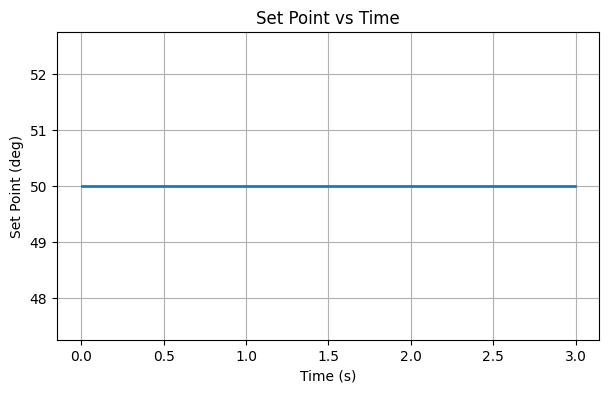

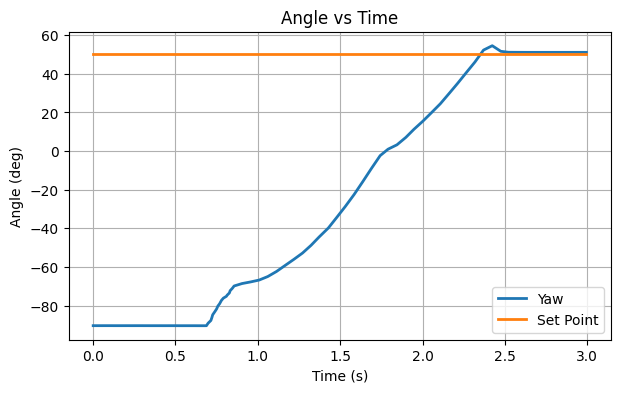

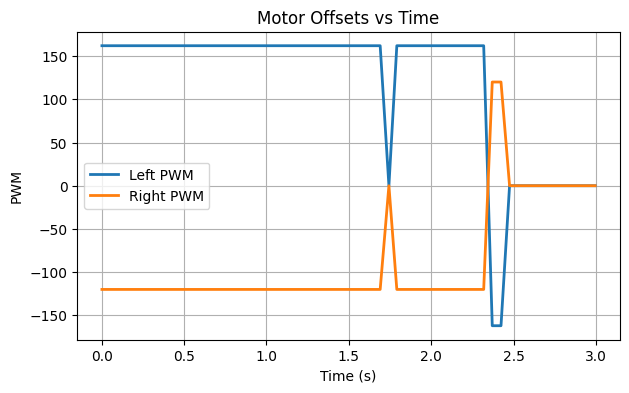

In [257]:
# =========================
# 3. 画图
# =========================

plt.figure(figsize=(7,4))
plt.plot(t, sp, linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Set Point (deg)")
plt.title("Set Point vs Time")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(t, yaw, linewidth=2, label="Yaw")
plt.plot(t, sp, linewidth=2, label="Set Point")
plt.xlabel("Time (s)")
plt.ylabel("Angle (deg)")
plt.title("Angle vs Time")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(7,4))
plt.plot(t, left_pwm, linewidth=2, label="Left PWM")
plt.plot(t, right_pwm, linewidth=2, label="Right PWM")
plt.xlabel("Time (s)")
plt.ylabel("PWM")
plt.title("Motor Offsets vs Time")
plt.legend()
plt.grid(True)
plt.show()